# Imports

In [4]:
# Instalar PyTorch con CUDA (primero, para evitar que sentence-transformers instale CPU)
%pip install -U torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128

Looking in indexes: https://download.pytorch.org/whl/cu128
Note: you may need to restart the kernel to use updated packages.


# Dataset and Preprocessing

In [5]:
import gc
import pandas as pd

from datasets import load_dataset
from datasets import Dataset

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM
)

In [6]:
dataset = load_dataset("wangrongsheng/ag_news")
df_text_train = pd.DataFrame(dataset["train"])
df_text_test = pd.DataFrame(dataset["test"])

In [7]:
MODEL_NAME = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
MAX_MODEL_LENGTH = 2048
MAX_LENGTH = 2048

In [8]:
label_token_dict = {
    0: "World",
    1: "Sports",
    2: "Business",
    3: "Science"
}

def build_prompt(review):

    prompt = f"""Article: {review}

Theme:"""

    return prompt


def build_full_text(review, label):

    theme = label_token_dict[label]

    full_text = f"""Article: {review}

Theme: {theme}"""

    return full_text


def preprocess_dataset(dataset, tokenizer):
    records = dataset.to_dict("records")

    reviews   = [r["text"]  for r in records]
    raw_labels = [r["label"] for r in records]

    full_texts   = [build_full_text(rev, lbl) for rev, lbl in zip(reviews, raw_labels)]
    prompt_texts = [build_prompt(rev) for rev in reviews]

    # tokenizacion en batch: 1 llamada en vez de N
    full_enc = tokenizer(
        full_texts,
        add_special_tokens=False,
        max_length=MAX_LENGTH,
        padding="max_length",
        truncation=True,
    )
    prompt_enc = tokenizer(
        prompt_texts,
        add_special_tokens=False,
    )

    labels_list = [
        [
            -100 if (i < len(prompt_ids) or attn == 0) else tok
            for i, (tok, attn) in enumerate(zip(input_ids, attention_mask))
        ]
        for input_ids, attention_mask, prompt_ids in zip(
            full_enc["input_ids"],
            full_enc["attention_mask"],
            prompt_enc["input_ids"],
        )
    ]

    true_labels_list = [label_token_dict[l] for l in raw_labels]

    return Dataset.from_dict({
        "input_ids":      full_enc["input_ids"],
        "attention_mask": full_enc["attention_mask"],
        "labels":         labels_list,
        "true_label":     true_labels_list,
    })

In [9]:
# Model tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

In [10]:
def fits_model(example):

    text = build_full_text(
        example["text"],
        example["label"]
    )

    tokens = tokenizer(
        text,
        add_special_tokens=False
    )["input_ids"]

    return len(tokens) <= MAX_MODEL_LENGTH

In [11]:
train_mask = df_text_train.groupby("label").cumcount() < 7500
df_masked_train = df_text_train[train_mask]
df_masked_train["label"].value_counts()

label
2    7500
3    7500
1    7500
0    7500
Name: count, dtype: int64

In [12]:
cumcount = df_text_train.groupby("label").cumcount()
val_mask = (cumcount >= 7500) & (cumcount < 7525)
df_masked_val = df_text_train[val_mask]
df_masked_val["label"].value_counts()

label
0    25
3    25
1    25
2    25
Name: count, dtype: int64

In [13]:
train_raw = df_masked_train
val_raw = df_masked_val
test_raw = df_text_test

In [14]:
# Reviews exceeding model context are removed from the dataset.
filtered_train = train_raw[train_raw.apply(fits_model, axis=1)]

filtered_val = val_raw[val_raw.apply(fits_model, axis=1)]

filtered_test = test_raw[test_raw.apply(fits_model, axis=1)]

In [15]:
train_dataset = preprocess_dataset(filtered_train, tokenizer)
val_dataset = preprocess_dataset(filtered_val, tokenizer)
test_dataset = preprocess_dataset(filtered_test, tokenizer)

In [16]:
print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

30000
100
7600


In [17]:
train_dataset.set_format(
    type="torch",
    columns=[
        "input_ids",
        "attention_mask",
        "labels",
        "true_label"
    ]
)

val_dataset.set_format(
    type="torch",
    columns=[
        "input_ids",
        "attention_mask",
        "labels",
        "true_label"
    ]
)

test_dataset.set_format(
    type="torch",
    columns=[
        "input_ids",
        "attention_mask",
        "labels",
        "true_label"
    ]
)

# Student definition

In [18]:
# LLM Model download
teacher_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME
)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 3575.22it/s]


In [19]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


In [20]:
teacher_model.load_state_dict(
      torch.load(
          "../checkpoints/agnews/best_teacher_model.pt",
          map_location=device
      )
  )

<All keys matched successfully>

In [21]:
teacher_model.to(device)

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(32000, 2048)
    (layers): ModuleList(
      (0-21): 22 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=256, bias=False)
          (v_proj): Linear(in_features=2048, out_features=256, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=2048, out_features=5632, bias=False)
          (up_proj): Linear(in_features=2048, out_features=5632, bias=False)
          (down_proj): Linear(in_features=5632, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((2048,), eps=1e-05)
    (rot

In [22]:
from transformers import AutoConfig

# cargar config del teacher
config = AutoConfig.from_pretrained(MODEL_NAME)

# reducir capas si querés student 11 capas
config.num_hidden_layers = 11

# crear student RANDOM
student_model = AutoModelForCausalLM.from_config(config)

In [23]:
student_model.to(device)

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(32000, 2048)
    (layers): ModuleList(
      (0-10): 11 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=256, bias=False)
          (v_proj): Linear(in_features=2048, out_features=256, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=2048, out_features=5632, bias=False)
          (up_proj): Linear(in_features=2048, out_features=5632, bias=False)
          (down_proj): Linear(in_features=5632, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((2048,), eps=1e-05)
    (rot

# Student training

In [24]:
def collate_fn(batch):
    input_ids      = [b["input_ids"].clone()      for b in batch]
    attention_mask = [b["attention_mask"].clone()  for b in batch]
    labels         = [b["labels"].clone()          for b in batch]
    true_labels    = [b["true_label"]              for b in batch]

    return {
        "input_ids":      torch.nn.utils.rnn.pad_sequence(input_ids,      batch_first=True, padding_value=tokenizer.pad_token_id),
        "attention_mask": torch.nn.utils.rnn.pad_sequence(attention_mask, batch_first=True, padding_value=0),
        "labels":         torch.nn.utils.rnn.pad_sequence(labels,         batch_first=True, padding_value=-100),
        "true_label":     true_labels,
    }

BATCH_SIZE = 1

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)

In [25]:
def save_checkpoint(model, optimizer, epoch, global_step, path="checkpoint.pt"):

    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "epoch": epoch,
            "global_step": global_step
        },
        path
    )

def load_checkpoint(model, optimizer, path="checkpoint.pt"):

    ckpt = torch.load(path, map_location=device)

    model.load_state_dict(ckpt["model_state_dict"])
    optimizer.load_state_dict(ckpt["optimizer_state_dict"])

    return ckpt["epoch"], ckpt["global_step"]

In [26]:
# =========================
# CONFIG DISTILLATION
# =========================
temperature = 2.0
alpha = 0.5
beta = 0.25
lr = 1e-4

EPOCHS = 3

teacher_model.eval()
student_model.train()

for p in teacher_model.parameters():
    p.requires_grad = False

optimizer = torch.optim.AdamW(
    student_model.parameters(),
    lr=lr
)

In [27]:
best_val_loss = float("inf")
eval_every = 1000
save_every = 2000
start_epoch = 0
global_step = 0
max_val_steps = 100

In [28]:
token_ids = [
    tokenizer.encode(f" {l}", add_special_tokens=False)[0]
    for l in ["World", "Sports", "Business", "Science"]
]
print(token_ids)

[2787, 12453, 15197, 9327]


In [29]:
try:
    start_epoch, global_step = load_checkpoint(
        student_model,
        optimizer,
        "../checkpoints/agnews/student_local_checkpoint.pt"
    )

    print(f"[RESUME] Epoch {start_epoch} | Global step {global_step}")

except:
    print("[START] Training from scratch")

# =========================
# INIT LOSS
# =========================

student_model.eval()

with torch.no_grad():
    batch = next(iter(train_loader))

    input_ids = batch["input_ids"].to(device)
    attention_mask = batch["attention_mask"].to(device)
    labels = batch["labels"].to(device)

    n_tokens = attention_mask.float().sum()

    teacher_outputs = teacher_model(
        input_ids=input_ids,
        attention_mask=attention_mask
    )

    student_outputs = student_model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        labels=labels
    )

    ce_loss = student_outputs.loss

    kd_global = F.kl_div(
        F.log_softmax(student_outputs.logits / temperature, dim=-1),
        F.softmax(teacher_outputs.logits / temperature, dim=-1),
        reduction="batchmean"
    ) * (temperature ** 2) / n_tokens

    # =========================
    # KD OBJ
    # =========================

    student_obj = student_outputs.logits[:, :, token_ids]
    teacher_obj = teacher_outputs.logits[:, :, token_ids]

    kd_obj = F.kl_div(
        F.log_softmax(student_obj / temperature, dim=-1),
        F.softmax(teacher_obj / temperature, dim=-1),
        reduction="batchmean"
    ) * (temperature ** 2) / n_tokens

    init_loss = alpha * ce_loss + (1 - alpha) * kd_global + beta * kd_obj

    print(
        f"[INIT LOSS] Total={init_loss.item():.4f} | "
        f"CE={ce_loss.item():.4f} | "
        f"KDg={kd_global.item():.4f} | "
        f"KDobj={kd_obj.item():.4f}"
    )

student_model.train()

# =========================
# TRAINING
# =========================

for epoch in range(start_epoch, EPOCHS):

    student_model.train()

    total_loss = 0
    total_ce = 0
    total_kd_global = 0
    total_kd_obj = 0

    for step, batch in enumerate(train_loader):

        global_step += 1

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        n_tokens = attention_mask.float().sum()

        # =========================
        # TEACHER
        # =========================

        with torch.no_grad():
            teacher_outputs = teacher_model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

        # =========================
        # STUDENT
        # =========================

        student_outputs = student_model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        ce_loss = student_outputs.loss

        kd_global = F.kl_div(
            F.log_softmax(student_outputs.logits / temperature, dim=-1),
            F.softmax(teacher_outputs.logits / temperature, dim=-1),
            reduction="batchmean"
        ) * (temperature ** 2) / n_tokens

        student_obj = student_outputs.logits[:, :, token_ids]
        teacher_obj = teacher_outputs.logits[:, :, token_ids]

        kd_obj = F.kl_div(
            F.log_softmax(student_obj / temperature, dim=-1),
            F.softmax(teacher_obj / temperature, dim=-1),
            reduction="batchmean"
        ) * (temperature ** 2) / n_tokens

        # =========================
        # LOSS FINAL
        # =========================

        loss = (
            alpha * ce_loss +
            (1 - alpha) * kd_global +
            beta * kd_obj
        )

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        # =========================
        # ACCUMULATORS
        # =========================

        total_loss += loss.item()
        total_ce += ce_loss.item()
        total_kd_global += kd_global.item()
        total_kd_obj += kd_obj.item()

        if global_step % 50 == 0:
            print(
                f"Epoch {epoch} | Step {step} | Global {global_step} | "
                f"Loss {total_loss/(step+1):.4f} | "
                f"CE {total_ce/(step+1):.4f} | "
                f"KDg {total_kd_global/(step+1):.4f} | "
                f"KDobj {total_kd_obj/(step+1):.4f}"
            )

        # =========================
        # VALIDATION
        # =========================

        if global_step % eval_every == 0:

            student_model.eval()

            val_loss = 0
            val_steps = 0

            with torch.no_grad():

                for val_batch in val_loader:

                    val_steps += 1

                    input_ids = val_batch["input_ids"].to(device)
                    attention_mask = val_batch["attention_mask"].to(device)
                    labels = val_batch["labels"].to(device)

                    n_tokens = attention_mask.float().sum()

                    teacher_outputs = teacher_model(
                        input_ids=input_ids,
                        attention_mask=attention_mask
                    )

                    student_outputs = student_model(
                        input_ids=input_ids,
                        attention_mask=attention_mask,
                        labels=labels
                    )

                    ce_loss = student_outputs.loss

                    kd_global = F.kl_div(
                        F.log_softmax(student_outputs.logits / temperature, dim=-1),
                        F.softmax(teacher_outputs.logits / temperature, dim=-1),
                        reduction="batchmean"
                    ) * (temperature ** 2) / n_tokens

                    student_obj = student_outputs.logits[:, :, token_ids]
                    teacher_obj = teacher_outputs.logits[:, :, token_ids]

                    kd_obj = F.kl_div(
                        F.log_softmax(student_obj / temperature, dim=-1),
                        F.softmax(teacher_obj / temperature, dim=-1),
                        reduction="batchmean"
                    ) * (temperature ** 2) / n_tokens

                    batch_loss = (
                        alpha * ce_loss +
                        (1 - alpha) * kd_global +
                        beta * kd_obj
                    )

                    val_loss += batch_loss.item()

                    if val_steps >= max_val_steps:
                        break

            val_loss /= val_steps

            print(f"\n[VAL LOSS] {val_loss:.4f}\n")

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0

                torch.save(
                    student_model.state_dict(),
                    "../checkpoints/agnews/best_student_local_model.pt"
                )

                print("[BEST MODEL SAVED]")

            else:
                patience_counter += 1

            save_checkpoint(
                student_model,
                optimizer,
                epoch,
                global_step,
                "../checkpoints/agnews/student_local_checkpoint.pt"
            )

        # =========================
        # CLEANUP
        # =========================

        del (
            input_ids,
            attention_mask,
            labels,
            teacher_outputs,
            student_outputs,
            ce_loss,
            kd_global,
            kd_obj,
            loss
        )

    gc.collect()

[START] Training from scratch
[INIT LOSS] Total=187.8610 | CE=10.1781 | KDg=357.0526 | KDobj=16.9825
Epoch 0 | Step 49 | Global 50 | Loss 44.9148 | CE 11.0918 | KDg 62.4085 | KDobj 32.6587
Epoch 0 | Step 99 | Global 100 | Loss 36.4893 | CE 6.8640 | KDg 51.4404 | KDobj 29.3482
Epoch 0 | Step 149 | Global 150 | Loss 30.4090 | CE 5.1605 | KDg 44.0490 | KDobj 23.2172
Epoch 0 | Step 199 | Global 200 | Loss 27.0238 | CE 4.2678 | KDg 39.4572 | KDobj 20.6452
Epoch 0 | Step 249 | Global 250 | Loss 24.6674 | CE 3.7224 | KDg 36.2517 | KDobj 18.7212
Epoch 0 | Step 299 | Global 300 | Loss 23.0538 | CE 3.3614 | KDg 34.1403 | KDobj 17.2119
Epoch 0 | Step 349 | Global 350 | Loss 21.9231 | CE 3.0908 | KDg 32.7272 | KDobj 16.0564
Epoch 0 | Step 399 | Global 400 | Loss 20.8332 | CE 2.8854 | KDg 31.3185 | KDobj 14.9249
Epoch 0 | Step 449 | Global 450 | Loss 20.1685 | CE 2.7270 | KDg 30.5299 | KDobj 14.1602
Epoch 0 | Step 499 | Global 500 | Loss 19.6365 | CE 2.5998 | KDg 29.8373 | KDobj 13.6717
Epoch 0 | S

In [30]:
student_model.load_state_dict(
    torch.load(
        "../checkpoints/agnews/best_student_local_model.pt",
        map_location=device
    )
)

<All keys matched successfully>

In [31]:
student_model.to(device)

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(32000, 2048)
    (layers): ModuleList(
      (0-10): 11 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=256, bias=False)
          (v_proj): Linear(in_features=2048, out_features=256, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=2048, out_features=5632, bias=False)
          (up_proj): Linear(in_features=2048, out_features=5632, bias=False)
          (down_proj): Linear(in_features=5632, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((2048,), eps=1e-05)
    (rot

In [32]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# =========================
# TARGET TOKENS
# =========================

CLASS_LABELS = ["World", "Sports", "Business", "Science"]

class_token_ids = [
    tokenizer.encode(f" {label}", add_special_tokens=False)[0]
    for label in CLASS_LABELS
]

# =========================
# TEST EVALUATION
# =========================

student_model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        true_labels = batch["true_label"]

        outputs = student_model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        last_idx = attention_mask.sum(dim=1) - 2

        logits = outputs.logits[
            torch.arange(input_ids.size(0), device=device),
            last_idx
        ]

        class_logits = logits[:, class_token_ids]
        pred_indices = class_logits.argmax(dim=-1)

        for pred_idx, t in zip(pred_indices, true_labels):
            y_pred.append(CLASS_LABELS[pred_idx.item()])
            y_true.append(t)

student_model.cpu()

# =========================
# METRICS
# =========================

test_accuracy = accuracy_score(y_true, y_pred)

test_precision = precision_score(
    y_true, y_pred,
    average="macro",
    zero_division=0,
    labels=CLASS_LABELS
)

test_recall = recall_score(
    y_true, y_pred,
    average="macro",
    zero_division=0,
    labels=CLASS_LABELS
)

test_f1 = f1_score(
    y_true, y_pred,
    average="macro",
    zero_division=0,
    labels=CLASS_LABELS
)

cm = confusion_matrix(y_true, y_pred, labels=CLASS_LABELS)

In [33]:
torch.set_printoptions(threshold=torch.inf)

In [34]:
torch.set_printoptions(threshold=torch.inf)

with torch.no_grad():
    for batch in test_loader:
        print(batch["input_ids"])
        print(batch["attention_mask"])
        print(batch["labels"])

        last_idx = batch["attention_mask"].sum(dim=1) - 2

        print(batch["input_ids"][0][last_idx])
        print(batch["attention_mask"][0][last_idx])
        print(batch["labels"][0][last_idx])

        break

tensor([[21746, 29901,   383, 15451,   363,   323,   405,   282,  2673,  1156,
          5969,  2039,   853,  1080, 15783, 17162,   472, 24215,   259,  1570,
           497,  1827,   896,   526,   525,  2218,   932,  2461,   287, 29915,
          1156,  5969,  2039,   411,   851, 21475,  3847,  9226, 14879,   341,
           468,   352, 29889,    13,    13, 17693, 29901, 15197,     2,     2,
             2,     2,     2,     2,     2,     2,     2,     2,     2,     2,
             2,     2,     2,     2,     2,     2,     2,     2,     2,     2,
             2,     2,     2,     2,     2,     2,     2,     2,     2,     2,
             2,     2,     2,     2,     2,     2,     2,     2,     2,     2,
             2,     2,     2,     2,     2,     2,     2,     2,     2,     2,
             2,     2,     2,     2,     2,     2,     2,     2,     2,     2,
             2,     2,     2,     2,     2,     2,     2,     2,     2,     2,
             2,     2,     2,     2,     2,     2,  

In [35]:
tokenizer.decode(15197)

'Business'

In [36]:
# =========================
# PRINT
# =========================

print("\n=========================")
print("[TEST RESULTS]")
print(f"Accuracy : {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1 Score : {test_f1:.4f}")
print("=========================\n")

print("[CONFUSION MATRIX]")
print(cm)


[TEST RESULTS]
Accuracy : 0.8804
Precision: 0.8816
Recall   : 0.8804
F1 Score : 0.8807

[CONFUSION MATRIX]
[[1658   43  110   89]
 [  28 1806   50   16]
 [  64   27 1582  227]
 [  50   24  181 1645]]


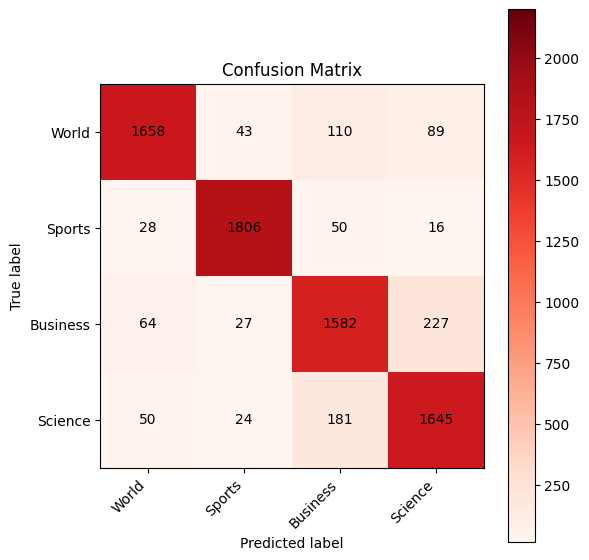

In [37]:
import matplotlib.pyplot as plt

n = len(CLASS_LABELS)

fig, ax = plt.subplots(figsize=(6, 6))

im = ax.imshow(cm, cmap="Reds", vmax=2200)

ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(CLASS_LABELS, rotation=45, ha="right")
ax.set_yticklabels(CLASS_LABELS)

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Confusion Matrix")

for i in range(n):
    for j in range(n):
        ax.text(j, i, cm[i, j],
                ha="center", va="center",
                color="black")

plt.colorbar(im)
plt.tight_layout()
plt.show()